# Source Injector

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly. 

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.

In [3]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from histpy import Histogram
from threeML import Powerlaw, Band, Model, PointSource
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file
import shutil
import os
import h5py as h5

%matplotlib inline

In [4]:
data_dir = Path("/Users/parshadkp/Software/COSI_Data/")

## Get the data
The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size. 

In [4]:
# response_path = data_dir/"DC2_Files/psr_gal_DC2.h5"
response_path = data_dir/"DC3_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse_nside8.area.good_chunks.h5"

In [5]:
%%capture
# orientation_path = data_dir/"DC2_Files/20280301_3_month_with_orbital_info.ori"
orientation_path = data_dir/"DC3_Files/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori" # DC3

# # download orientation file ~684.38 MB
# if not orientation_path.exists():
#     fetch_wasabi_file("COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori", orientation_path)

## Inject a source response

### Method 2: Read the spectrum from a file

In this method, we're loading spectral data from a file (crab_spec.dat) and visualizing it:

In [6]:
# Load data from the text file, skipping the index column
dataFlux = np.genfromtxt(data_dir/"AGN_Data/GammaRay/NGC_1068_ec200_COSI.dat",comments = "#",usecols = (2),skip_footer=1,skip_header=5)
dataEn = np.genfromtxt(data_dir/"AGN_Data/GammaRay/NGC_1068_ec200_COSI.dat",comments = "#",usecols = (1),skip_footer=1,skip_header=5)


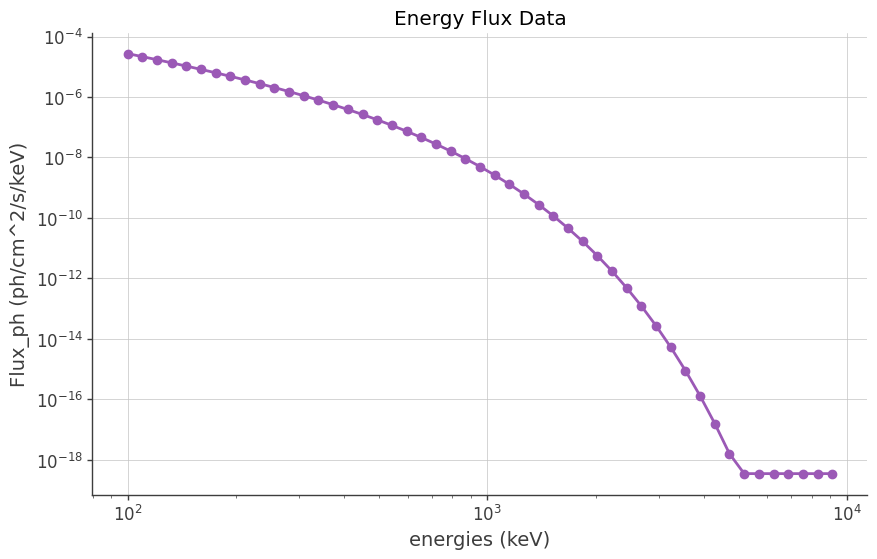

In [7]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dataEn, dataFlux, label="NGC1068 200 keV Cutoff", marker="o", linestyle="-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("energies (keV)")
# plt.ylabel("Flux (keV cm^-2 s^-1)")
plt.ylabel("Flux_ph (ph/cm^2/s/keV)")
plt.title("Energy Flux Data")
plt.grid(True)
plt.show()

We use a custom class `SpecFromDat` to define a spectrum from data loaded from a CSV file `crab_spec.dat`


### SpecFromDat Class Explanation

The `SpecFromDat` class represents a spectrum loaded from a data file (`dat`, `txt`, `csv` etc.,). It provides methods to handle spectral data and evaluate the spectrum at specified energy values (`x`).

#### Class Description

- **Description**: 
  - A spectrum loaded from a data file (`dat`).

#### Parameters

- **K**:
  - **Description**: Normalization factor.
  - **Initial Value**: 1.0
  - **Is Normalization**: True
  - **Transformation**: log10
  - **Min**: 1e-30
  - **Max**: 1e3
  - **Delta**: 0.1
  - **Units**: `ph/cm2/s`

#### Properties

- **dat**:
  - **Description**: The data file from which the spectrum is loaded.
  - **Initial Value**: `test.dat`
  - **Defer**: True
  - **Units**:
    - **Energy**: `keV`.
    - **Flux**: `ph/cm2/s/keV`.
 
#### Functionality

- Loads flux (`dataFlux`) and energy (`dataEn`) from the specified data file (`self.dat.value`).
- Normalizes `dataFlux` using the widths of energy bins.
- Interpolates (`interp1d`) the normalized data to create a function (`fun`) for evaluating the spectrum.
- Evaluates the spectrum (`fun(x)`) at given energy values (`x`), scaled by the normalization factor (`K`).

In [6]:
spectrum = SpecFromDat(K=0.00152, dat=data_dir/"AGN_Data/GammaRay/NGC_1068_ec200_COSI.dat")

In [7]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=17.2, b=-51.9, frame = "galactic", unit = "deg")

# define the Crab point source
point_source = PointSource('NGC1068_ec200', l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape = spectrum)

# define the model. One model can contain multiple point sources.
model = Model(point_source)

### Read orientation file

In [8]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(orientation_path)

### Get the expected counts and save to a data file

In [9]:
# Define an injector by the response
# injector = SourceInjector(response_path = response_path)
injector = SourceInjector(response_path = response_path) # For galactic frame response file

CPU times: user 1min 19s, sys: 3.83 s, total: 1min 23s
Wall time: 1min 24s


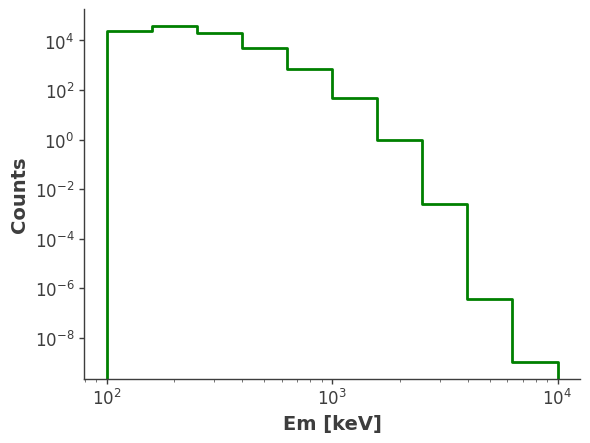

In [10]:
%%time

file_path = data_dir/"AGN_Data/GammaRay/DC3/NGC_1068_ec200_COSI.hdf5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

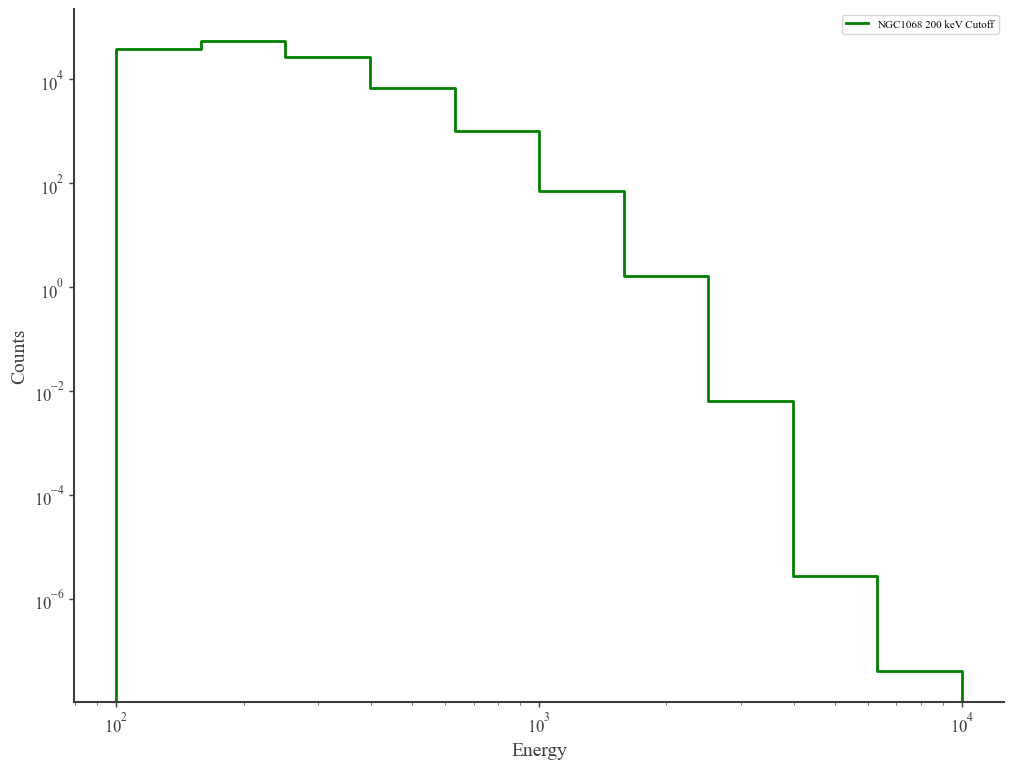

In [30]:
NGC1068_ec200 = Histogram.open(data_dir/"AGN_Data/GammaRay/NGC_1068_ec200_COSI.hdf5")

fig, ax = plt.subplots(figsize=(12, 9))
NGC1068_ec200.project("Em").draw(ax, label="NGC1068 200 keV Cutoff", color="green")

ax.set_yscale("log")
ax.set_xscale("log")

# ax.set_ylim(1e0, 1e8)
ax.set_ylabel("Counts")
ax.set_xlabel("Energy")
plt.legend()

# Combine background and source data

In [11]:
# read the background file
# bkg_hist = Histogram.open(data_dir/"DC2_Files/bkg_binned_data.hdf5")
# bkg_hist = Histogram.open(data_dir/"DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
# bkg_hist = Histogram.open(data_dir/"DC2_Files/total_bg_3months_binned_for_continuum.hdf5") #DC2 Background
bkg_hist = Histogram.open(data_dir/"DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5") #DC3 Background

# read the injected source file
ngc_hist = Histogram.open(data_dir/"AGN_Data/GammaRay/DC3/NGC_1068_ec200_COSI.hdf5")

In [12]:
ngc_hist.axes["Em"].axis_scale = "linear"

In [13]:
ngc_hist.axes["Em"].axis_scale

'linear'

In [14]:
bkg_hist.axes["Em"].axis_scale

'linear'

In [15]:
# We need to process the background and source data file to:
# 1. match the axes (including name and scale)
# 2. match the data unit

# collapse the time axis of the backgroun data
bkg_hist = bkg_hist.project(['Em', 'Phi', 'PsiChi'])

# reset the source data unit to the same one that the background data has
# bkg_hist = bkg_hist.to(unit = ngc_hist.unit)
ngc_hist = ngc_hist.to(unit = bkg_hist.unit, update = False)

In [16]:
for ax1, ax2 in zip(ngc_hist.axes, bkg_hist.axes):
    print(ax1.label)
    print(ax2.label)
    print("Equal?", ax1 == ax2)
    print()

Em
Em
Equal? True

Phi
Phi
Equal? True

PsiChi
PsiChi
Equal? True



In [ ]:
# Now you can add up the background and source dataall_daya = ngc_hist + bkg_hist
ngc_hist.write(data_dir/"AGN_Data/GammaRay/DC3/NGC_1068_ec200_corrected_COSI.hdf5")
ngc_bkg = ngc_hist + bkg_hist
ngc_bkg.write(data_dir/"AGN_Data/GammaRay/DC3/NGC_1068_ec200_bkg_COSI.hdf5")

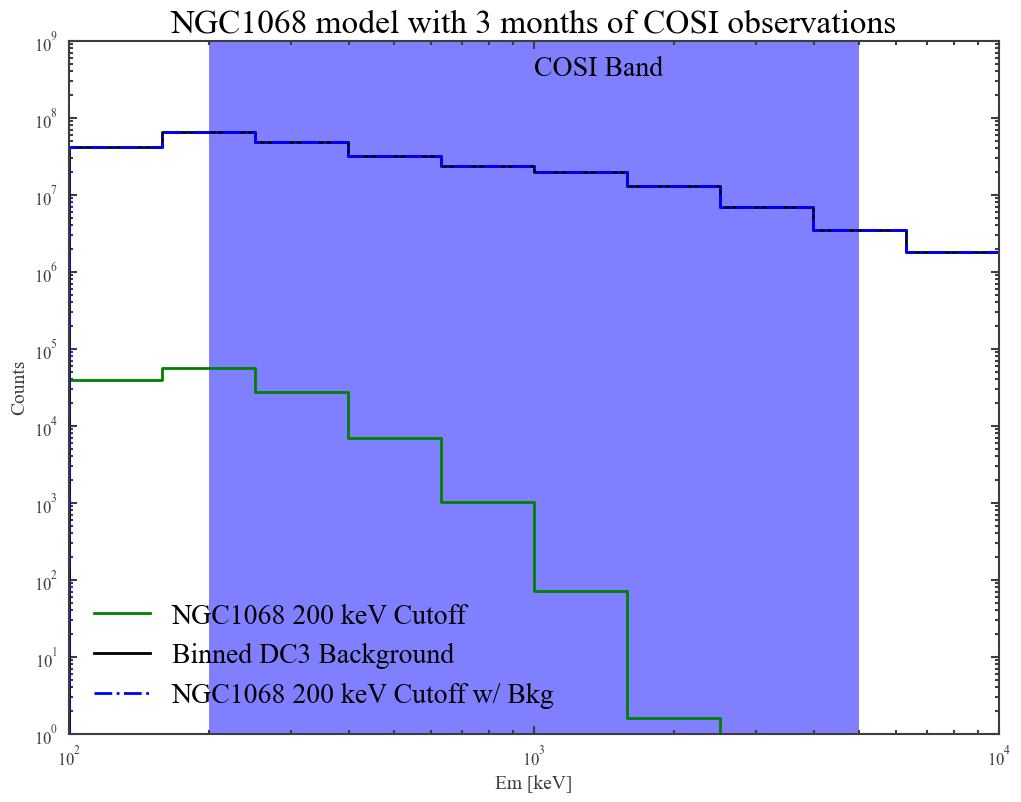

NGC1068 Counts (0.2-10 MeV):  129588.22833994743
Background Counts (0.2-10 MeV):  255807443.0
Sigma NGC1068:  8.100260550204005


In [3]:
# NGC1068 = Histogram.open(data_dir/"AGN_Data/GammaRay/NGC_1068_ec200_corrected_COSI.hdf5")
# NGC1068_bkg = Histogram.open(data_dir / "AGN_Data/GammaRay/NGC_1068_ec200_bkg_COSI.hdf5")
# bkg_hist = Histogram.open(data_dir/"DC2_Files/bkg_binned_data.hdf5")

NGC1068 = Histogram.open(data_dir/"AGN_Data/GammaRay/DC2/NGC_1068_ec200_corrected_COSI.hdf5")
NGC1068_bkg = Histogram.open(data_dir / "AGN_Data/GammaRay/DC2/NGC_1068_ec200_Totalbkg_COSI.hdf5")
bkg_hist = Histogram.open(data_dir/"DC2_Files/total_bg_3months_binned_for_continuum.hdf5")

plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(12, 9))

NGC1068.project("Em").draw(ax, label="NGC1068 200 keV Cutoff", color="green")
bkg_hist.project("Em").draw(ax, label="Binned DC3 Background", color="black")
NGC1068_bkg.project("Em").draw(ax, label="NGC1068 200 keV Cutoff w/ Bkg", linestyle='dashdot', color="blue")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)


ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left', frameon=False)
ax.set_ylabel("Counts")
ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.5, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC1068 model with 3 months of COSI observations")
# ax.set_title("Crab model with 3 months of COSI observations")
plt.show()

### 0.2 - 5 MeV ###
# Sum_NGC1068 = np.sum(NGC1068.project("Em").slice[1:8])
# Sum_bkg_hist = np.sum(bkg_hist.project("Em").slice[1:8])
# Sigma_NGC1068 = Sum_NGC1068/(np.sqrt(Sum_NGC1068+Sum_bkg_hist))

# print("NGC1068 Counts (0.2-5 MeV): ", Sum_NGC1068)
# print("Background Counts (0.2-5 MeV): ", Sum_bkg_hist)
# print("Sigma NGC1068: ", Sigma_NGC1068)

### 0.2 - 10 MeV ###
Sum_NGC1068 = np.sum(NGC1068.project("Em"))
Sum_bkg_hist = np.sum(bkg_hist.project("Em"))
Sigma_NGC1068 = Sum_NGC1068/(np.sqrt(Sum_NGC1068+Sum_bkg_hist))

print("NGC1068 Counts (0.2-10 MeV): ", Sum_NGC1068)
print("Background Counts (0.2-10 MeV): ", Sum_bkg_hist)
print("Sigma NGC1068: ", Sigma_NGC1068)

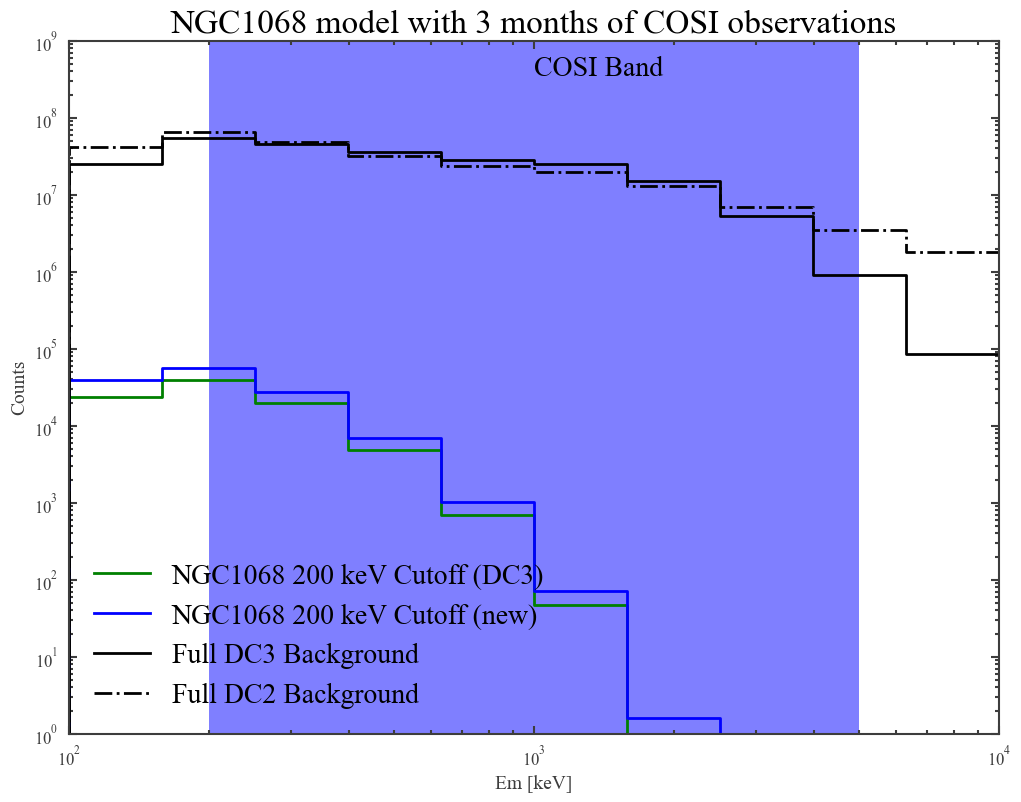

NGC1068 DC2 (0.2-10 MeV):  129588.22833994743
NGC1068 DC3 (0.2-10 MeV):  88384.01294669935
Sigma DC2:  8.100260550204005
Sigma DC3:  5.7575253831635855


In [10]:
NGC1068_DC2 = Histogram.open(data_dir/"AGN_Data/GammaRay/DC2/NGC_1068_ec200_corrected_COSI.hdf5")
NGC1068_DC3 = Histogram.open(data_dir / "AGN_Data/GammaRay/DC3/NGC_1068_ec200_corrected_COSI.hdf5")
bkg_hist_DC3 = Histogram.open(data_dir/"DC3_Files/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
bkg_hist_DC2 = Histogram.open(data_dir/"DC2_Files/total_bg_3months_binned_for_continuum.hdf5")

plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(12, 9))

NGC1068_DC3.project("Em").draw(ax, label="NGC1068 200 keV Cutoff (DC3)", color="green")
NGC1068_DC2.project("Em").draw(ax, label="NGC1068 200 keV Cutoff (new)", color="blue")
bkg_hist_DC3.project("Em").draw(ax, label="Full DC3 Background", color="black")
bkg_hist_DC2.project("Em").draw(ax, label="Full DC2 Background", linestyle='dashdot', color="black")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)


ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left', frameon=False)
ax.set_ylabel("Counts")
ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.5, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC1068 model with 3 months of COSI observations")
plt.show()

### 0.2 - 10 MeV ###
Sum_NGC1068_DC3 = np.sum(NGC1068_DC3.project("Em"))
Sum_NGC1068_DC2 = np.sum(NGC1068_DC2.project("Em"))
Sum_bkg_hist_DC3 = np.sum(bkg_hist_DC3.project("Em"))
Sum_bkg_hist_DC2 = np.sum(bkg_hist_DC2.project("Em"))
Sigma_NGC1068_DC3 = Sum_NGC1068_DC3/(np.sqrt(Sum_NGC1068_DC3+Sum_bkg_hist_DC3))
Sigma_NGC1068_DC2 = Sum_NGC1068_DC2/(np.sqrt(Sum_NGC1068_DC2+Sum_bkg_hist_DC2))

print("NGC1068 DC2 (0.2-10 MeV): ", Sum_NGC1068_DC2)
print("NGC1068 DC3 (0.2-10 MeV): ", Sum_NGC1068_DC3)
# print("Background Counts (0.2-10 MeV): ", Sum_bkg_hist)
print("Sigma DC2: ", Sigma_NGC1068_DC2)
print("Sigma DC3: ", Sigma_NGC1068_DC3)